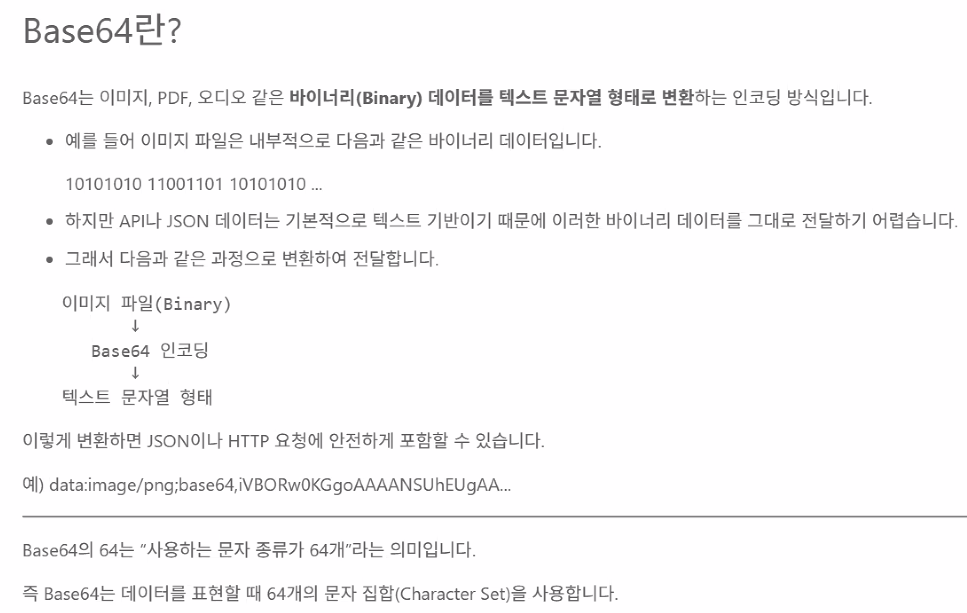

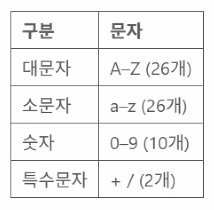

In [1]:
from dotenv import load_dotenv
from openai import OpenAI

# Base64 인코딩을 위한 라이브러리
import base64

# .env 파일에 저장된 OPENAI_API_KEY를 Python 환경 변수로 등록합니다.
load_dotenv()

# OpenAI API 서버와 통신할 클라이언트 객체 생성합니다.
client = OpenAI()

# 이미지 파일을 binary 모드("rb")로 읽은 뒤 Base64로 인코딩합니다.
# Base64는 바이너리 데이터를 텍스트 문자열로 변환하는 방식입니다.
#
with open("output/page_high_res.png", "rb") as f:
    # f.read() : 파일을 바이너리 그대로 읽음
    # base64.b64encode(f.read()) : 바이너리를 Base64 형식으로 변환(bytes)
    # .decode("utf-8") : bytes -> 문자열(str) 변환
    image_base64 = base64.b64encode(f.read()).decode("utf-8")

# data URL 형식 생성
# OpenAI API에서 이미지 전달 시 data URL 형식을 사용할 수 있습니다.
# 형식
# data:image/png;base64,Base64데이터
image_data_url = f"data:image/png;base64,{image_base64}"

# Base64로 변환한 이미지를 모델에게 전달하여 분석을 요청합니다.
response = client.responses.create(
    # 사용할 AI 모델
    model="gpt-4.1-nano",

    # 모델에게 전달할 입력 데이터
    input=[
        {
            "role": "user",
            "content": [

                # 텍스트 질문
                {
                    "type": "input_text",
                    "text": "이 이미지 설명해줘"
                },

                # Base64 방식 이미지 전달
                {
                    "type": "input_image",

                    # Base64 data URL 형태로 이미지 전달
                    "image_url": image_data_url
                }
            ]
        }
    ],

    max_output_tokens=100
)

print(response.output_text)

이 이미지는 학술지 논문 초록 부분으로, 제목은 "과정기반 작물모델을 이용한 웹 기반 및 재배관리 의사결정 지원시스템 설계 및 구축"이며, 영어 제목은 "Design and Development of Web-Based Decision Support Systems for Wheat Management Practices Using Process-Based Crop Model"입니다. 저자는 김솔희, 석승원, 정리광, 장태일, 김태곤이며, 주요 내용은 밀
